## Library

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score
from dotenv import load_dotenv
from google.cloud import bigquery
warnings.filterwarnings("ignore")

In [2]:
load_dotenv()

PROJECT_ROOT = Path.cwd().parents[0]  # jupyter/ -> bgg/
DATA_DIR = PROJECT_ROOT / "data" / "after"
CACHE_DIR = DATA_DIR / "nb_cache_03"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
PROJECT_ID = os.environ["GCP_PROJECT_ID"]
client = bigquery.Client(project=PROJECT_ID)

print(f"ROOT:\t{PROJECT_ROOT}")
print(f"CACHE:\t{CACHE_DIR}")
print(f"GCP:\tConnected to Project: {client.project}")

ROOT:	/Users/mungughyeon/Documents/internship/Likelion/bgg
CACHE:	/Users/mungughyeon/Documents/internship/Likelion/bgg/data/after/nb_cache_03
GCP:	Connected to Project: bgg-user-analytics


In [3]:
import sys
sys.path.insert(0, str(PROJECT_ROOT))
from src.utils import setup_font


def load_cache(name: str, sql: str, refresh: bool = False) -> pd.DataFrame:
    """캐시 CSV가 있으면 그걸 읽고, 없거나 refresh=True면 BigQuery에 쿼리해 캐시"""
    cache_path = CACHE_DIR / f"{name}.csv"
    if not cache_path.exists() or refresh:
        client.query(sql).to_dataframe().to_csv(cache_path, index=False)
    return pd.read_csv(cache_path)

Hangul OK in your MAC!


<a id="sec-bg"></a>
## 배경

- [EDA](01.EDA.ipynb)에서 유저 활동량은 소수에 극단적으로 쏠려 있음을 확인했다(지니계수 0.78~0.80).
    - 평균적인 유저 한 명으로 전체를 설명할 수 없다는 뜻이며, 유저를 몇 가지 유형으로 나눠 볼 필요성이 여기서 도출된다.
- [Funnel 분석](02.Funnel_Retention.ipynb)은 나눔의 기준 자체를 점검했다. 
    - 보유 게임이 많은 유저일수록 "플레이 기록이 있는지 없는지"라는 이진 기준은 쉽게 충족하지만, 소유 게임 대비 실제로 기록하는 비율(`play_game_ratio`)은 오히려 낮아지는 경향이 관찰됐다. 
    - 보유 게임 수만으로 유저를 나누면 실제 참여 수준이 다른 유저를 같은 집단으로 묶을 위험이 있다.
- 이 분석은 다음 질문에서 출발한다. 
    - 보유 게임이 많은 유저는 정말 활발한 유저인가? 
    - 보유 게임 수와 실제 활용도를 분리한 세그먼트를 정의하고, 세그먼트별로 게임 선택·평가·활동·위시리스트 행동이 실제로 다르게 관찰되는지 확인한다.

In [4]:
SEGMENT_COLORS = {
    "0.미플레이": "#9CA3AF",   # 회색
    "1.몰입형": "#2E7D6B",     # 초록
    "2.수집가형": "#E0A72E",   # 앰버
    "3.집중형": "#3B82C4",     # 파랑
    "4.저관여형": "#D9776B",   # 산호
}
SEGMENT_ORDER = list(SEGMENT_COLORS.keys())
PLAYER_ORDER = SEGMENT_ORDER[1:]
TIER_COLORS = {"1.소프트유저": "#B7D3E8", "2.미들유저": "#5B9BD5", "3.하드유저": "#1F4E79"}  # 순서가 있는 축이라 단색 계조

In [5]:
funnel_user = load_cache("funnel_user", '''
    SELECT * FROM `bgg_mart.funnel_user`
''')

funnel_item = load_cache("funnel_item", '''
    SELECT * FROM `bgg_mart.funnel_item`
''')

user_segment = load_cache("user_segment", '''
    SELECT * FROM `bgg_mart.user_segment`
''')

user_info = load_cache("user_info_03", '''
    SELECT user_id, yearregistered, lastlogin FROM `bgg_staging.stg_user_info`
''')

item_stats = load_cache("item_stats_03", '''
    SELECT objectid, averageweight, bayesaverage, owned FROM `bgg_staging.stg_item_stats`
''')

item_category = load_cache("item_category_03", '''
    SELECT objectid, category FROM `bgg_staging.item_category`
''')

# 유저 개인 평점(rating_diff 계산용) - funnel.sql과 같은 dedup+백필 규칙
user_rating = load_cache("user_rating_03", '''
    WITH latest_row AS (
        SELECT user_id, objectid, user_rating, lastmodified
        FROM `bgg_staging.stg_user_item`
        QUALIFY ROW_NUMBER() OVER (PARTITION BY user_id, objectid ORDER BY lastmodified DESC) = 1
    ),
    latest_rating AS (
        SELECT user_id, objectid, user_rating AS latest_nonnull_rating
        FROM `bgg_staging.stg_user_item`
        WHERE user_rating IS NOT NULL
        QUALIFY ROW_NUMBER() OVER (PARTITION BY user_id, objectid ORDER BY lastmodified DESC) = 1
    )
    SELECT l.user_id, l.objectid, COALESCE(l.user_rating, r.latest_nonnull_rating) AS user_rating
    FROM latest_row l LEFT JOIN latest_rating r USING (user_id, objectid)
''')

# 위시리스트 - 여기서 처음 dedup(01의 user_item과 같은 중복 패턴)
user_wishlist = load_cache("user_wishlist_03", '''
    SELECT user_id, objectid, own, wishlist, wishlistpriority
    FROM `bgg_staging.stg_user_wishlist`
    QUALIFY ROW_NUMBER() OVER (PARTITION BY user_id, objectid ORDER BY lastmodified DESC) = 1
''')

print(f"funnel_user {funnel_user.shape}, funnel_item {funnel_item.shape}, user_wishlist {user_wishlist.shape}")

funnel_user (3000, 8), funnel_item (1295519, 7), user_wishlist (160019, 5)


<a id="sec-1"></a>
## 1. 총 플레이량 기준 세그먼트의 한계

- `bgg_mart.user_segment`는 유저를 총 플레이량(numplays 합계) 3분위로 나눠 이미 소프트/미들/하드유저로 구분해 두었다.
- 이 축을 그대로 쓰기 전에, 총 플레이량이 보유 게임 수와 얼마나 겹치는지 확인한다. 
- 두 값이 강하게 연결돼 있다면 총 플레이량은 사실상 보유 게임 수의 대리 지표에 가까워, 보유 게임 수와 실제 활용도를 구분하는 축으로 쓰기 어렵다.

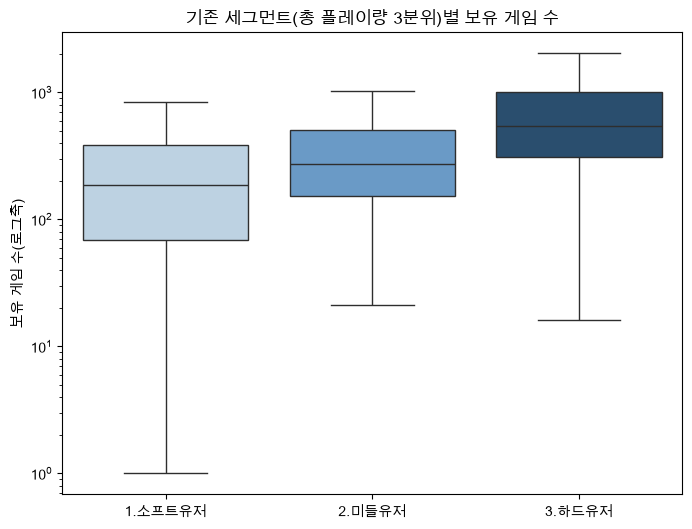

segment
1.소프트유저    186.0
2.미들유저     275.0
3.하드유저     546.0
Name: n_owned, dtype: float64

In [6]:
seg_owned = funnel_user[funnel_user["is_owner"]].merge(user_segment[["user_id", "segment"]], on="user_id", how="left")

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=seg_owned, x="segment", y="n_owned", order=list(TIER_COLORS.keys()),
            palette=TIER_COLORS, showfliers=False, ax=ax)
ax.set_yscale("log")
ax.set_title("기존 세그먼트(총 플레이량 3분위)별 보유 게임 수")
ax.set_xlabel("")
ax.set_ylabel("보유 게임 수(로그축)")
plt.show()

seg_owned.groupby("segment")["n_owned"].median()

**결과**

- 하드유저는 보유 게임이 중앙값 546개로, 소프트유저(186개)보다 약 3배 많은 것으로 확인
- 총 플레이량 3분위가 사실상 보유 게임 수 3분위와 유사하게 작동한다는 것을 시사
- 총 플레이량 하나로는 "보유 게임이 많아서 플레이 총량도 큰 유저"와 "가진 것 대비 실제로 많이 플레이하는 유저"를 구분할 수 없다는 것을 시사
- 그렇기 때문에 보유 게임 수(`n_owned`)와 별개로 실제 활용도를 나타내는 축이 필요하며, 다음 절에서 두 축을 분리해 정의한다


<a id="sec-2"></a>
## 2. 보유 게임 수 × 활용도 2×2 세그먼트 정의

- 보유 게임이 있는 2,944명 중, [Funnel 분석](02.Funnel_Retention.ipynb)에서 플레이한 적이 없는 것으로 확인된 956명을 먼저 분리
- 이 구간은 Funnel 상 감소 폭이 가장 컸던 지점으로, 나머지 세그먼트와 같은 축(보유 게임 수·활용도)으로 비교하기보다 별도 집단으로 두고 그 안에서 무엇이 관찰되는지 따로 확인
- 남은 1,988명(플레이한 유저)을 두 축으로 나눈다.
    - 보유 게임 수(`n_owned`): 얼마나 많은 게임을 보유하는가.
    - `play_game_ratio`: 보유한 게임 중 실제로 플레이한 게임의 비율. 
    - 보유 게임 수와 무관하게, 가진 것을 얼마나 실제로 소화하는지를 나타낸다.
- 두 축을 분리하는 이유는 1절과 바로 이어진다. 
    - 보유 게임 수만으로는 "많이 갖고 많이 쓰는 유저"와 "많이 갖고 있지만 일부만 쓰는 유저"를 구분할 수 없다. 
    - `play_game_ratio`를 보유 게임 수와 별개의 축으로 두면 이 둘을 분리해서 볼 수 있다.

### 2-0. 플레이한 적이 없는 유저는 무엇을 하는가

- 플레이한 적이 없다는 사실이 게임 자체에 대한 무관심을 뜻하는지, 평가 참여율로 확인한다.

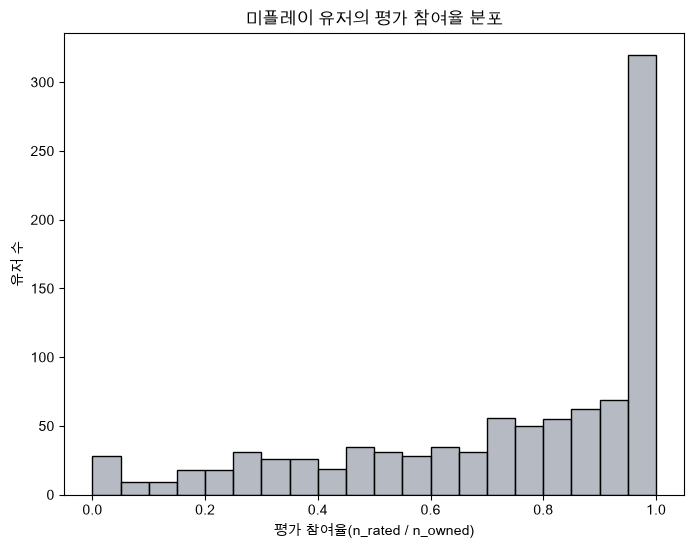

미플레이 유저: 956명
그중 평점을 하나라도 남긴 비율: 99.0%
평가 참여율 중앙값: 0.82


In [7]:
nonplayers = funnel_user[funnel_user["is_owner"] & ~funnel_user["has_play_record"]].copy()
nonplayers["rating_ratio"] = nonplayers["n_rated"] / nonplayers["n_owned"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(nonplayers["rating_ratio"], bins=20, color=SEGMENT_COLORS["0.미플레이"], ax=ax)
ax.set_title("미플레이 유저의 평가 참여율 분포")
ax.set_xlabel("평가 참여율(n_rated / n_owned)")
ax.set_ylabel("유저 수")
plt.show()

print(f"미플레이 유저: {len(nonplayers):,}명")
print(f"그중 평점을 하나라도 남긴 비율: {(nonplayers['rating_ratio'] > 0).mean():.1%}")
print(f"평가 참여율 중앙값: {nonplayers['rating_ratio'].median():.2f}")

**결과**

- 플레이한 적이 없는 956명 중 99%가 평점을 하나 이상 남긴 것으로 확인, 절반은 소유 게임의 82% 이상을 평가
    - 평가 참여율만 놓고 보면 이 그룹은 낮지 않음
- 플레이 여부와 평가 참여는 서로 다른 지표라는 것이 확인됨
    - 다만 `numplays`는 유저가 직접 남긴 값이므로([EDA](01.EDA.ipynb) 8-0), 이 관찰이 실제 플레이 여부에 대해 무엇을 말해주는지는 방향성 정도로만 해석한다
    - [Trend 분석](04.Trend.ipynb) 2-2에서 실제 플레이 로그로 이 유보를 정량화: 미플레이 라벨 검증 가능 표본(340명) 중 28명(8.2%, 95% CI 5.8~11.6%)은 실제로는 플레이 기록이 있는 것으로 확인(오탐 하한 추정)
    - 다만 평가 참여율이 높을수록 오분류 가능성이 높다는 가설은 그 표본(n=28)에서 뒷받침되지 않음(방향 반대, 유의하지 않음) — 표본이 작아 판단은 보류


### 2-1. 보유 게임 수 × 활용도 2×2

- 두 축을 각각 중앙값 기준으로 나눠 교차하면 네 유형이 만들어진다. 

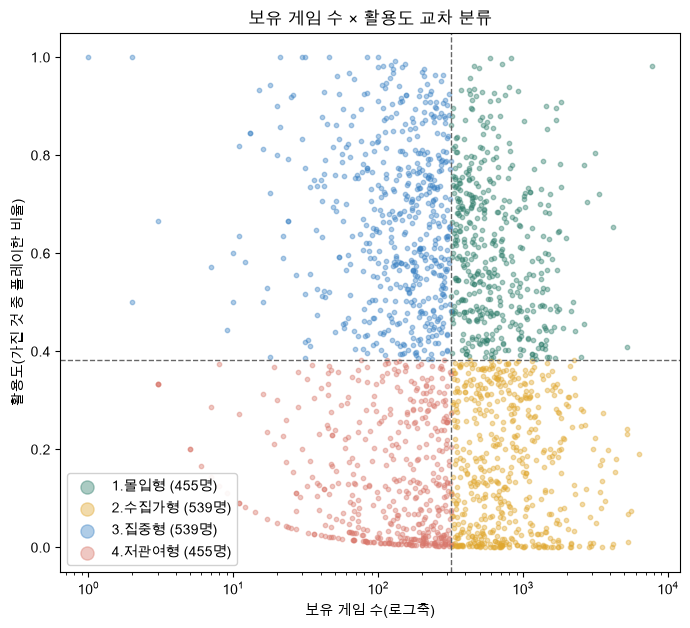

segment5
1.몰입형     455
2.수집가형    539
3.집중형     539
4.저관여형    455
Name: count, dtype: int64

In [8]:
players = funnel_user[funnel_user["is_owner"] & funnel_user["has_play_record"]].copy()
players = players.merge(user_info, on="user_id", how="left")
players["rating_ratio"] = players["n_rated"] / players["n_owned"]
play_ratio = funnel_item.groupby("user_id")["has_play_record"].mean().rename("play_game_ratio")
players = players.merge(play_ratio, on="user_id", how="left")

med_owned = players["n_owned"].median()
med_ratio = players["play_game_ratio"].median()

players["segment5"] = np.select(
    [
        (players["n_owned"] >= med_owned) & (players["play_game_ratio"] >= med_ratio),
        (players["n_owned"] >= med_owned) & (players["play_game_ratio"] < med_ratio),
        (players["n_owned"] < med_owned) & (players["play_game_ratio"] >= med_ratio),
    ],
    ["1.몰입형", "2.수집가형", "3.집중형"],
    default="4.저관여형",
)

fig, ax = plt.subplots(figsize=(8, 7))
for seg in PLAYER_ORDER:
    d = players[players.segment5 == seg]
    ax.scatter(d["n_owned"], d["play_game_ratio"], s=10, alpha=0.4,
               color=SEGMENT_COLORS[seg], label=f"{seg} ({len(d):,}명)")
ax.axvline(med_owned, color="#666666", linestyle="--", linewidth=1)
ax.axhline(med_ratio, color="#666666", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("보유 게임 수(로그축)")
ax.set_ylabel("활용도(가진 것 중 플레이한 비율)")
ax.set_title("보유 게임 수 × 활용도 교차 분류")
ax.legend(loc="lower left", markerscale=3, framealpha=0.9)
plt.show()

players["segment5"].value_counts().reindex(PLAYER_ORDER)

**결과**

- 네 유형은 인원이 비슷하게(455~539명) 나뉘는 것으로 확인
- 보유 게임 수만 보면 수집가형(539명)과 몰입형(455명)이 유사한 수준이지만, `play_game_ratio` 기준으로는 서로 반대편에 위치하는 것으로 확인
- 보유 게임 수 하나로는 이 두 유형을 구분할 수 없다는 것이 이 교차표로 드러남
- 보유 게임 수와 활용도를 분리한 근거가 여기서 확인된다


### 2-2. 다른 변수를 더했을 때도 이 구분이 보이는가

- 2×2를 정의한 두 변수(보유 게임 수, `play_game_ratio`)에 평가 관대함(`rating_ratio`)과 로그인 최근성을 추가로 넣어 K-means를 적용한다.
- 사전에 정의한 경계 없이, 이 4개 변수만으로 데이터를 알아서 4개 그룹으로 나눴을 때 2×2와 얼마나 겹치는지, 그리고 2×2에 없던 새로운 축이 드러나는지 확인한다.

2x2와 K-means의 일치도(0=무관, 1=완전 동일): 0.29


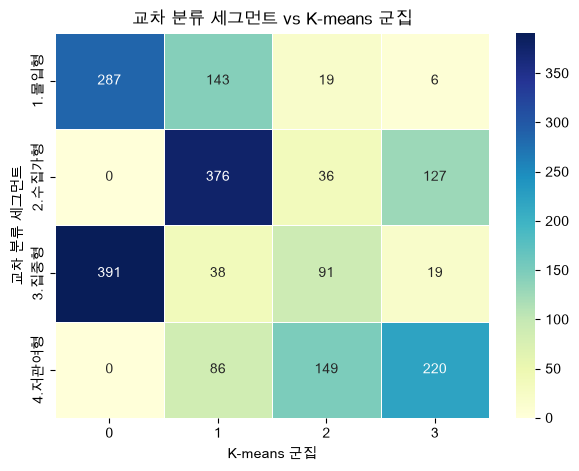

,n_owned,play_game_ratio,rating_ratio,days_since_login
kmeans_cluster,,,,
0,383.7,0.7,0.7,12.2
1,904.5,0.3,0.3,27.4
2,215.6,0.3,0.7,1124.0
3,361.2,0.1,0.8,14.8


In [9]:
players["log_owned"] = np.log1p(players["n_owned"])
players["days_since_login"] = (pd.Timestamp("2026-09-07") - pd.to_datetime(players["lastlogin"], errors="coerce")).dt.days
players["log_dsl"] = np.log1p(players["days_since_login"].fillna(players["days_since_login"].median()))

feat_cols = ["log_owned", "play_game_ratio", "rating_ratio", "log_dsl"]
X = players[feat_cols].fillna(players[feat_cols].median())
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_scaled)
players["kmeans_cluster"] = kmeans.labels_

ari = adjusted_rand_score(players["segment5"], players["kmeans_cluster"])
print(f"2x2와 K-means의 일치도(0=무관, 1=완전 동일): {ari:.2f}")

ct = pd.crosstab(players["segment5"], players["kmeans_cluster"])
plt.figure(figsize=(7, 5))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)
plt.title("교차 분류 세그먼트 vs K-means 군집")
plt.xlabel("K-means 군집")
plt.ylabel("교차 분류 세그먼트")
plt.show()

players.groupby("kmeans_cluster")[["n_owned", "play_game_ratio", "rating_ratio", "days_since_login"]].mean().round(1)

**결과**

- 2×2 구조와 군집화 결과의 일치도는 0.29로 확인
    - 다만 이 비교는 2×2 정의에 안 쓴 변수 2개(평가 관대함, 로그인 최근성)를 추가로 넣은 상태라, 2×2 경계 자체가 얼마나 잘 재현되는지를 공정하게 비교한 것은 아님(정확히 같은 2개 변수로만 비교한 결과는 2-3 참고)
- 보유 게임이 많은 몰입형·수집가형은 군집화 결과에서도 유사한 묶음으로 재현되는 것으로 확인
- 다만 네 군집 중 하나는 보유 게임 수나 `play_game_ratio`가 아니라 마지막 로그인 경과일(중앙값 약 3년)로 구분되는 것으로 확인
    - 보유 게임 수·활용도 축만으로는 드러나지 않는 활동 시점 축이 데이터에 존재할 가능성을 시사하는 탐색적 결과
    - 이 축의 의미는 [Trend 분석](04.Trend.ipynb)에서 실제 플레이 로그 기준으로 별도 검증한다

### 2-3. 2×2와 정확히 같은 변수로 공정 비교

- 2-2는 추가 변수(평가 관대함, 로그인 최근성)까지 넣은 상태라, 2×2 경계 자체가 데이터에서도 재현되는지를 순수하게 보려면 2×2를 정의한 변수 2개(보유 게임 수, `play_game_ratio`)만으로 비교해야 한다.
- 같은 두 변수로 K-means(k=4)를 다시 돌리고, 군집 품질을 실루엣 계수로 함께 확인한다.
    - 실루엣 계수는 각 점이 자기 군집에 얼마나 잘 속하고 다른 군집과는 얼마나 떨어져 있는지를 -1~1로 나타낸 값이다. 0에 가까우면 군집 간 경계가 흐릿하다는 뜻이다.

2x2 vs K-means(k=4, 동일 2변수) 일치도: 0.64
K-means(k=4) 실루엣 계수: 0.35
2x2 라벨 실루엣 계수: 0.32


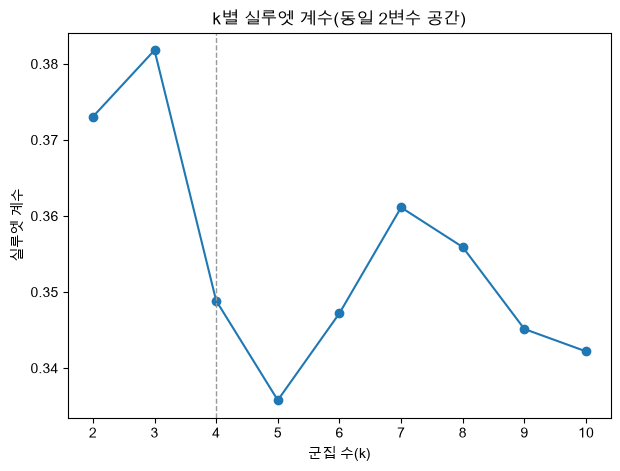

,k,silhouette
0,2,0.373044
1,3,0.381801
2,4,0.348869
3,5,0.335782
4,6,0.347212
5,7,0.361128
6,8,0.355913
7,9,0.345140
8,10,0.342197


In [10]:
players["log_owned"] = np.log1p(players["n_owned"])
feat_cols2 = ["log_owned", "play_game_ratio"]
X2 = players[feat_cols2].fillna(players[feat_cols2].median())
X2_scaled = StandardScaler().fit_transform(X2)

kmeans2 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X2_scaled)
players["kmeans_cluster_2var"] = kmeans2.labels_

ari2 = adjusted_rand_score(players["segment5"], players["kmeans_cluster_2var"])
sil_kmeans2 = silhouette_score(X2_scaled, kmeans2.labels_)
sil_2x2 = silhouette_score(X2_scaled, players["segment5"])

print(f"2x2 vs K-means(k=4, 동일 2변수) 일치도: {ari2:.2f}")
print(f"K-means(k=4) 실루엣 계수: {sil_kmeans2:.2f}")
print(f"2x2 라벨 실루엣 계수: {sil_2x2:.2f}")

sil_curve = []
for k in range(2, 11):
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X2_scaled)
    sil_curve.append({"k": k, "silhouette": silhouette_score(X2_scaled, km_k.labels_)})
sil_curve_df = pd.DataFrame(sil_curve)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(sil_curve_df["k"], sil_curve_df["silhouette"], marker="o")
ax.axvline(4, color="#999999", linestyle="--", linewidth=1)
ax.set_xlabel("군집 수(k)")
ax.set_ylabel("실루엣 계수")
ax.set_title("k별 실루엣 계수(동일 2변수 공간)")
plt.show()

sil_curve_df

**결과**

- 2×2와 정확히 같은 2개 변수로 비교하니 일치도가 0.64로 확인, 2-2의 4변수 비교(0.29)보다 훨씬 높음
    - 사전에 정의한 경계 없이 데이터만으로 나눠도 2×2와 상당 부분 같은 방식으로 갈린다는 것을 시사
- K-means(k=4) 실루엣 계수 0.35, 2×2 라벨 실루엣 계수 0.32로 확인, 두 값이 비슷한 수준
    - 손으로 그은 경계가 알고리즘이 찾은 경계와 품질 면에서 큰 차이가 없다는 것을 시사
- k=2~10 전 구간 실루엣 계수가 0.33~0.38 사이로 확인, k=3에서 근소하게 가장 높고 k=4는 그보다 살짝 낮음
    - 이 데이터에는 뚜렷하게 나뉘는 자연스러운 군집 개수가 없고, 어떤 k를 택해도 품질이 비슷하다는 것을 시사
    - 따라서 4개 그룹은 데이터가 스스로 알려준 답이 아니라, 보유 게임 수 × 활용도라는 두 축을 해석 가능하게 보기 위해 분석자가 정한 프레임이라는 것으로 확인

<a id="sec-3"></a>
## 3. 세그먼트별 행동 특성 비교

- 정의한 5개 유형(미플레이 + 4개 플레이어 유형)이 보유 게임 수·활용도 수치뿐 아니라 실제 게임 선택·평가·활동 시점에서도 다르게 관찰되는지 확인
- 세그먼트 정의에 쓴 변수(`n_owned`, `play_game_ratio`)와 무관한 지표에서 차이가 나타난다면, 이 구분이 단순한 수치상의 차이를 넘어 실제 행동 차이로 이어진다는 근거가 된다.

### 3-1. 실제로 플레이하는 게임의 복잡도

- 세그먼트 정의에 복잡도는 관여하지 않았다. 
- 세그먼트별 실제 플레이 게임의 복잡도를 비교해, 정의에 쓰지 않은 축에서도 차이가 나타나는지 확인한다.

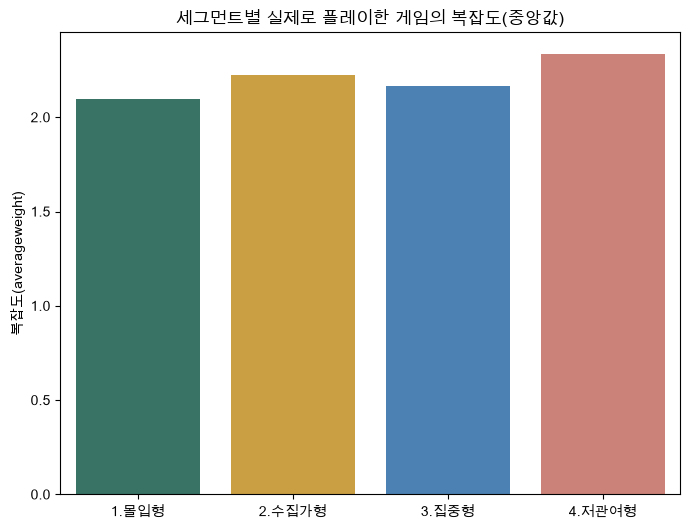

,mean,median
segment5,,
1.몰입형,2.20,2.10
2.수집가형,2.31,2.22
3.집중형,2.28,2.17
4.저관여형,2.43,2.33


In [11]:
owners = funnel_user[funnel_user["is_owner"]].copy()
owners["segment5"] = "0.미플레이"
for seg in PLAYER_ORDER:
    owners.loc[owners.user_id.isin(players[players.segment5 == seg].user_id), "segment5"] = seg

item_j = funnel_item.merge(owners[["user_id", "segment5"]], on="user_id", how="left")
played = item_j[item_j.has_play_record & (item_j.averageweight > 0)]

cx = played.groupby("segment5")["averageweight"].median().reindex(PLAYER_ORDER)

plt.figure(figsize=(8, 6))
sns.barplot(x=cx.index, y=cx.values, palette=[SEGMENT_COLORS[s] for s in PLAYER_ORDER])
plt.title("세그먼트별 실제로 플레이한 게임의 복잡도(중앙값)")
plt.xlabel("")
plt.ylabel("복잡도(averageweight)")
plt.show()

played.groupby("segment5")["averageweight"].agg(["mean", "median"]).reindex(PLAYER_ORDER).round(2)

**결과**

- 중앙값 기준 몰입형(2.10)에서 저관여형(2.33)까지 완만한 차이가 관찰됨
- 폭은 크지 않지만, 보유 게임이 많고 활용도도 높은 몰입형이 오히려 더 가벼운 게임 위주로 플레이하는 경향은 예상과 다른 방향
- 저관여형은 플레이 기록 자체가 적어(n=9,666, 몰입형 n=205,928) 표본이 작다는 점을 감안


### 3-2. 선호 카테고리

- 게임 유형(카테고리) 선택이 세그먼트에 따라 달라지는지 확인한다.

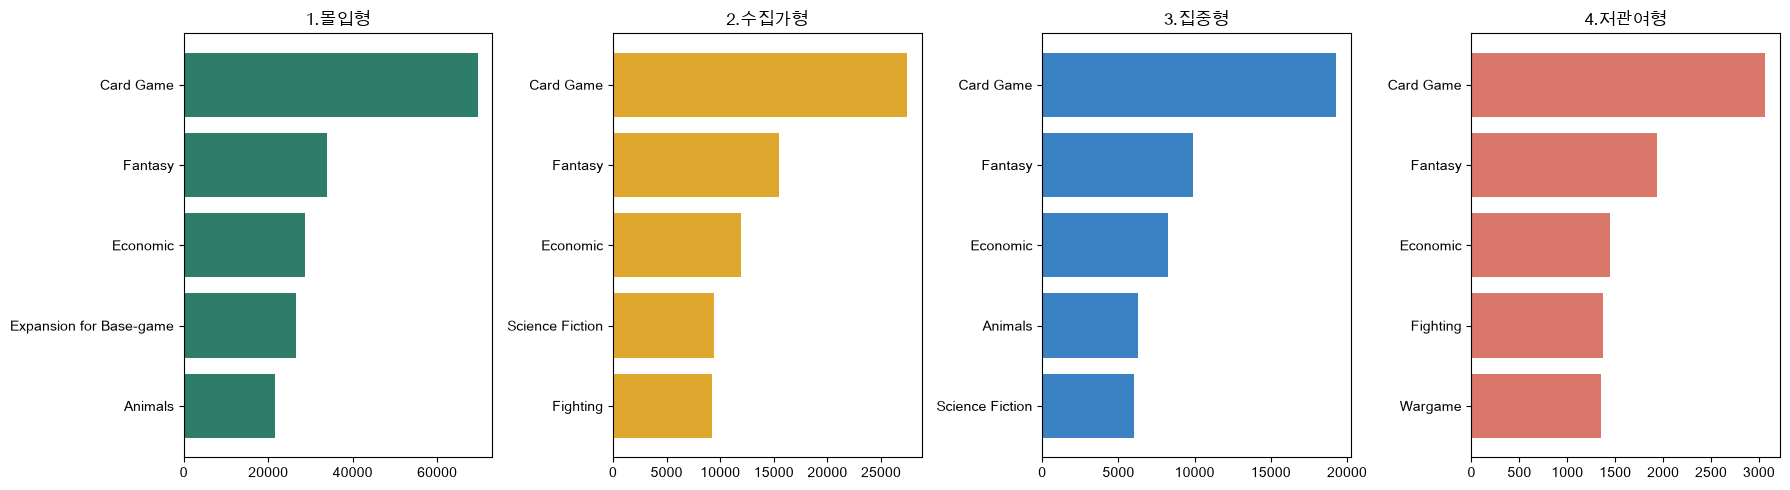

In [12]:
cat_j = item_j[item_j.has_play_record].merge(item_category, on="objectid", how="inner")

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
for ax, seg in zip(axes, PLAYER_ORDER):
    top5 = cat_j[cat_j.segment5 == seg]["category"].value_counts().head(5).sort_values()
    ax.barh(top5.index, top5.values, color=SEGMENT_COLORS[seg])
    ax.set_title(seg)
plt.tight_layout()
plt.show()

**결과**

- 카테고리 자체는 네 유형 사이에 거의 다르지 않은 것으로 확인, 모두 카드 게임·판타지·경제 게임을 가장 많이 플레이
- 차이는 4~5위권에서 나타남
    - 몰입형만 유일하게 "확장판(Expansion for Base-game)"이 상위권에 있고, 수집가형·저관여형은 전쟁·전투 테마가 상위권에 있는 것으로 확인
    - 몰입형에서 확장판 비중이 높게 나타나는 현상은 새 게임을 넓게 시도하기보다 이미 보유한 게임 계열을 반복해서 플레이하는 경향과 함께 관찰된다


### 3-3. 개인 평점과 게임 평균 평점의 차이

- [EDA](01.EDA.ipynb)의 6-3에서 정의한 `rating_diff`(개인 평점 - 게임 평균 평점)를 세그먼트별로 비교해, 평가 성향에서도 차이가 관찰되는지 확인한다.

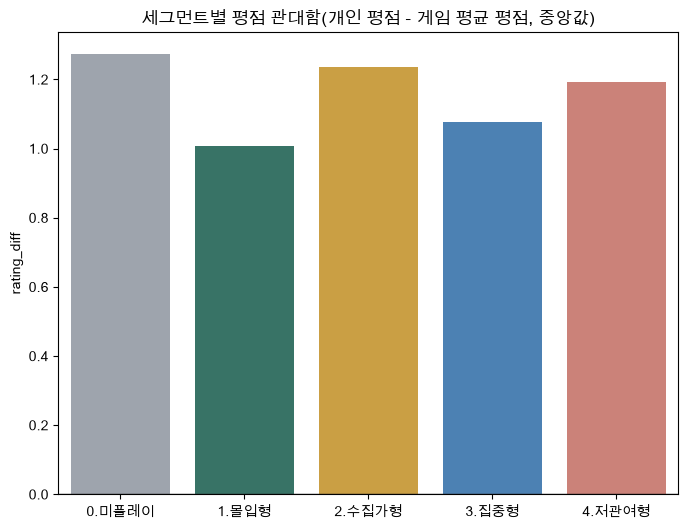

,mean,median
segment5,,
0.미플레이,1.26,1.27
1.몰입형,0.98,1.01
2.수집가형,1.20,1.24
3.집중형,1.07,1.08
4.저관여형,1.16,1.19


In [13]:
rp = user_rating[user_rating.user_rating.notna()].merge(
    item_stats[item_stats.bayesaverage > 0][["objectid", "bayesaverage"]], on="objectid"
)
rp["rating_diff"] = rp.user_rating - rp.bayesaverage
rp = rp.merge(owners[["user_id", "segment5"]], on="user_id", how="left")

rd = rp.groupby("segment5")["rating_diff"].median().reindex(SEGMENT_ORDER)

plt.figure(figsize=(8, 6))
sns.barplot(x=rd.index, y=rd.values, palette=[SEGMENT_COLORS[s] for s in SEGMENT_ORDER])
plt.axhline(0, color="#333333", linewidth=1)
plt.title("세그먼트별 평점 관대함(개인 평점 - 게임 평균 평점, 중앙값)")
plt.xlabel("")
plt.ylabel("rating_diff")
plt.show()

rp.groupby("segment5")["rating_diff"].agg(["mean", "median"]).reindex(SEGMENT_ORDER).round(2)

**결과**

- 다섯 유형 모두 게임 평균 평점보다 후하게 평가하지만, 정도에는 차이가 있는 것으로 확인
    - `play_game_ratio`가 가장 높은 몰입형이 가장 낮은 rating_diff(0.98), 미플레이 유저와 수집가형이 가장 높음(각각 1.26, 1.20)
- 플레이를 많이, 성실하게 하는 유형일수록 평가가 상대적으로 박하고 플레이가 적은 유형일수록 후한 경향이 함께 관찰된다
- [EDA](01.EDA.ipynb) 6-3에서 확인한 전체 경향(평균 +1.13) 안에서 세그먼트 간 차이가 존재하는 것으로 확인


### 3-4. 마지막 로그인 경과일

- [Funnel 분석](02.Funnel_Retention.ipynb)에서 로그인 경과일은 플레이 여부와 관련 있으나 원인 변수로 보지 않는다고 확인한 바 있다. 
- 여기서는 세그먼트 정의(보유 게임 수·활용도)와 로그인 최근성이 서로 다른 정보를 담는지 확인한다.

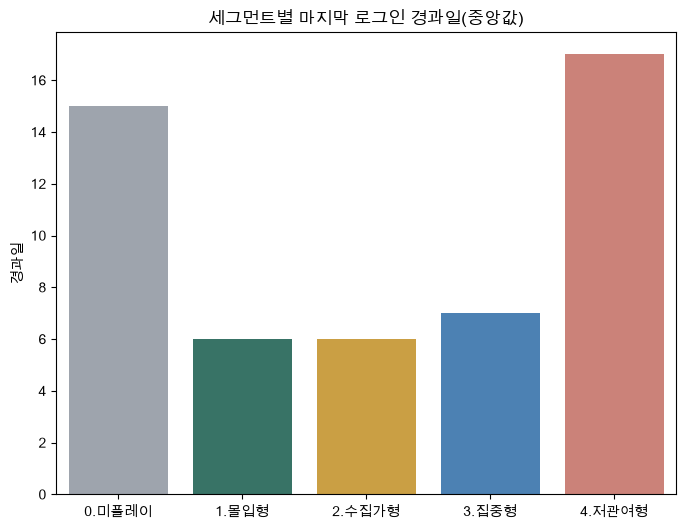

segment5
0.미플레이    15.0
1.몰입형      6.0
2.수집가형     6.0
3.집중형      7.0
4.저관여형    17.0
Name: days_since_login, dtype: float64

In [14]:
dsl_all = owners.merge(user_info, on="user_id", how="left")
dsl_all["days_since_login"] = (pd.Timestamp("2026-09-07") - pd.to_datetime(dsl_all["lastlogin"], errors="coerce")).dt.days
dsl_med = dsl_all.groupby("segment5")["days_since_login"].median().reindex(SEGMENT_ORDER)

plt.figure(figsize=(8, 6))
sns.barplot(x=dsl_med.index, y=dsl_med.values, palette=[SEGMENT_COLORS[s] for s in SEGMENT_ORDER])
plt.title("세그먼트별 마지막 로그인 경과일(중앙값)")
plt.xlabel("")
plt.ylabel("경과일")
plt.show()

dsl_med

**결과**

- 몰입형·수집가형·집중형은 로그인 경과일 중앙값이 일주일 이내인 반면, 저관여형과 미플레이 유저는 2주를 넘는 것으로 확인
- 수집가형은 로그인 빈도가 몰입형과 비슷한데도 `play_game_ratio`는 낮은 것으로 확인
    - 로그인 최근성과 플레이 활용도가 항상 같은 방향으로 움직이지는 않는다는 것을 시사
    - 세그먼트를 보유 게임 수나 로그인 빈도만으로 판단하면 놓칠 수 있는 차이


<a id="sec-4"></a>
## 4. 위시리스트로 본 관심 표시와 실제 행동의 관계

- [EDA](01.EDA.ipynb) 1-7에서 수집했으나 활용하지 않았던 위시리스트를 보조 지표로 사용한다. 
- 위시리스트에 담는 행위는 관심을 나타내는 신호 중 하나일 뿐, 구매나 플레이 의도를 직접 나타낸다고 보기는 어렵다. 
- 위시리스트에 담아둔 게임과 실제 플레이한 게임 사이의 관계를 세그먼트별로 관찰해, 
- 관심 표시와 실제 행동 사이에 나타나는 차이를 확인하는 수준으로 다룬다.

### 4-1. 위시리스트와 실제 플레이의 복잡도 비교

- 세그먼트별로 위시리스트에 담은 게임의 평균 복잡도와 실제로 플레이한 게임의 평균 복잡도를 비교해, 
- 두 수치 사이의 차이가 세그먼트마다 다르게 나타나는지 확인한다.

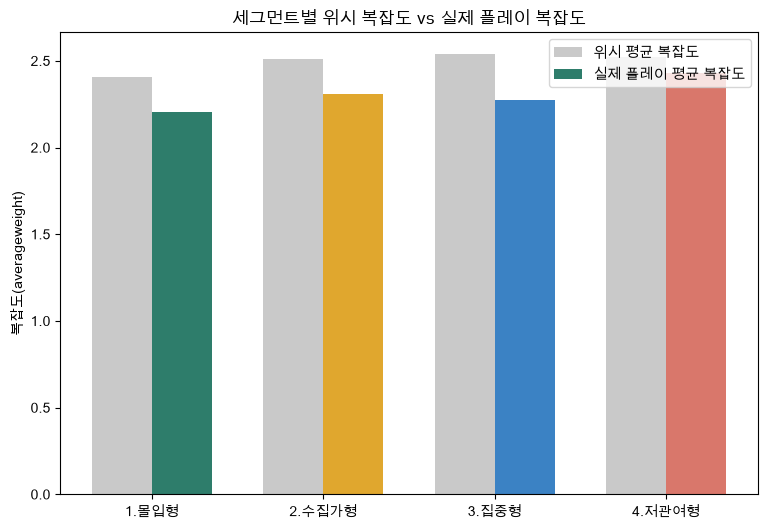

,위시 평균 복잡도,실제 플레이 평균 복잡도,갭(위시 - 실제)
segment5,,,
1.몰입형,2.407,2.203,0.205
2.수집가형,2.513,2.309,0.204
3.집중형,2.537,2.276,0.261
4.저관여형,2.520,2.433,0.088


In [15]:
wish_j = user_wishlist.merge(item_stats[["objectid", "averageweight"]], on="objectid", how="left")
wish_j = wish_j.merge(owners[["user_id", "segment5"]], on="user_id", how="left")
wish_valid = wish_j[wish_j.averageweight > 0]

wish_avg = wish_valid.groupby("segment5")["averageweight"].mean().reindex(PLAYER_ORDER)
played_avg = played.groupby("segment5")["averageweight"].mean().reindex(PLAYER_ORDER)

x = np.arange(len(PLAYER_ORDER))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width / 2, wish_avg.values, width, label="위시 평균 복잡도", color="#C9C9C9")
ax.bar(x + width / 2, played_avg.values, width, label="실제 플레이 평균 복잡도",
       color=[SEGMENT_COLORS[s] for s in PLAYER_ORDER])
ax.set_xticks(x)
ax.set_xticklabels(PLAYER_ORDER)
ax.set_ylabel("복잡도(averageweight)")
ax.set_title("세그먼트별 위시 복잡도 vs 실제 플레이 복잡도")
ax.legend()
plt.show()

gap = pd.DataFrame({"위시 평균 복잡도": wish_avg, "실제 플레이 평균 복잡도": played_avg})
gap["갭(위시 - 실제)"] = gap["위시 평균 복잡도"] - gap["실제 플레이 평균 복잡도"]
gap.round(3)

**결과**

- 네 유형 모두 위시리스트 평균 복잡도가 실제 플레이 평균 복잡도보다 높은 것으로 확인(차이 0.09~0.26)
- 갭이 가장 큰 쪽은 집중형(0.26)으로 확인
    - 적은 보유 게임을 집중적으로 플레이하는 이 유형에서, 위시리스트에 담아둔 게임의 복잡도와 실제로 플레이하는 게임의 복잡도 사이 격차가 가장 크게 나타남
    - 위시리스트에 담는 행위와 실제 플레이 대상 선택이 반드시 같은 기준을 따르지는 않는다는 것을 시사, 다만 그 이유는 이 데이터로 확인할 수 없다


### 4-2. 위시리스트 사용 여부와 위시 항목의 실제 소유·플레이 비율

- 세그먼트별로 위시리스트를 사용하는 유저의 비율과, 
- 위시리스트에 담긴 게임이 이후 소유·플레이로 이어지는 비율을 함께 확인

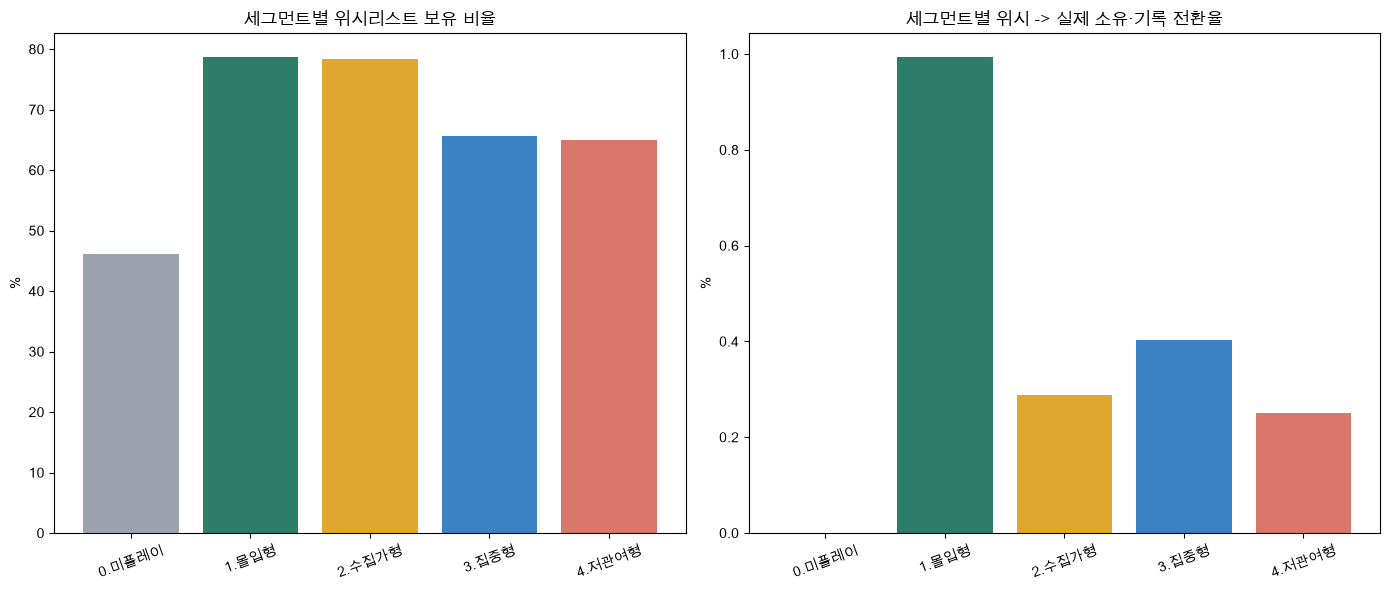

,위시 보유 비율,위시 전환율
segment5,,
0.미플레이,0.4613,0.0
1.몰입형,0.7868,0.009934
2.수집가형,0.7829,0.002887
3.집중형,0.6568,0.004032
4.저관여형,0.6505,0.002504


In [16]:
wishlist_users = set(user_wishlist["user_id"].unique())
owners["has_wishlist"] = owners["user_id"].isin(wishlist_users)
wish_usage = owners.groupby("segment5")["has_wishlist"].mean().reindex(SEGMENT_ORDER)

owned_played = funnel_item[funnel_item.has_play_record][["user_id", "objectid"]].assign(converted=True)
wp = user_wishlist.merge(owned_played, on=["user_id", "objectid"], how="left")
wp["converted"] = wp["converted"].fillna(False)
wp = wp.merge(owners[["user_id", "segment5"]], on="user_id", how="left")
wish_convert = wp.groupby("segment5")["converted"].mean().reindex(SEGMENT_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].bar(wish_usage.index, wish_usage.values * 100, color=[SEGMENT_COLORS[s] for s in SEGMENT_ORDER])
axes[0].set_title("세그먼트별 위시리스트 보유 비율")
axes[0].set_ylabel("%")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(wish_convert.index, wish_convert.values * 100, color=[SEGMENT_COLORS[s] for s in SEGMENT_ORDER])
axes[1].set_title("세그먼트별 위시 -> 실제 소유·기록 전환율")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

pd.DataFrame({"위시 보유 비율": wish_usage, "위시 전환율": wish_convert}).round(4)

**결과**

- 위시리스트 사용 비율은 세그먼트별로 다른 것으로 확인
    - 몰입형·수집가형은 10명 중 8명이 위시리스트를 사용하지만, 미플레이 유저는 절반에 못 미침
    - 위시리스트 사용은 보유 게임 활용도와는 별개로 세그먼트 간 참여 양상의 차이를 보여주는 지표로 관찰됨
- 반면 위시리스트에 담긴 게임이 이후 소유·플레이로 이어지는 비율은 모든 세그먼트에서 1% 안팎으로 낮은 것으로 확인
    - 몰입형이 상대적으로 높지만(다른 유형의 2~4배 수준) 절대 수준 자체는 낮음
    - 위시 우선순위(`wishlistpriority`)별로 나눠 봐도 이 비율에 일관된 차이는 나타나지 않는 것으로 확인
- 위시리스트에 담는 행위를 이후 소유·플레이로 이어지는 예고 지표로 보기는 어렵다는 것을 시사


<a id="sec-5"></a>
## 5. 결론

- 보유 게임이 많다는 사실만으로는 유저의 실제 참여 수준을 판단할 수 없는 것으로 확인
    - 몰입형과 수집가형은 보유 게임 수가 비슷한데도 가진 것 중 실제로 플레이한 비율은 서로 정반대
    - 보유 게임 수만 기준으로 나누면(1절의 총 플레이량 3분위 등) 이 두 유형이 한 집단으로 묶임
    - 두 축을 분리하면 이 차이가 드러나고, 같은 두 변수로 돌린 군집화 결과와도 일치도 0.64로 상당 부분 겹침

- 다만 이 네 유형이 데이터에 원래 존재하던 자연스러운 집단은 아닌 것으로 확인
    - 군집이 얼마나 뚜렷하게 갈리는지 재는 실루엣 계수가 0.32~0.35로 낮고, 그룹 수를 2개부터 10개까지 바꿔도 값이 거의 그대로(0.33~0.38)
    - 즉 몇 개로 나누는 게 맞다고 데이터가 알려주는 지점이 없음

네 유형이 자연스러운 집단이 아니라도 이 구분을 계속 쓸 수 있다. 이 구분의 근거는 "데이터가 알아서 찾아준 경계"가 아니라 "정의에 쓰지 않은 지표에서도 유형별 차이가 실제로 나타난다"는 데 있기 때문이다. 유형을 나눌 때 쓴 건 보유 게임 수와 활용도 두 가지뿐인데, 실제로 플레이하는 게임의 복잡도, 선호 카테고리 4~5위권, 평점을 후하게 주는 정도, 마지막 로그인 시점, 위시리스트 사용 비율까지 전부 유형별로 갈렸다. 정의에 안 쓴 것에서 차이가 난다는 건 이 틀이 실제 행동의 무언가를 잡아내고 있다는 뜻이다.

다만 복잡도처럼 차이 폭이 크지 않은 지표도 있어서, 방향성 있는 경향으로 읽되 확정적인 차이로 단정하지는 않는다.

| 세그먼트 | 인원 | 관찰된 특징 |
|---|---|---|
| 미플레이 | 956 | 플레이한 적 없음. 평가 참여율 중앙값 82% |
| 몰입형 | 455 | 많이 갖고 잘 씀. 평점을 가장 박하게 줌(0.98), 확장판 선호 상위권 |
| 수집가형 | 539 | 많이 갖지만 일부만 씀. 로그인은 몰입형과 비슷하게 잦고, 평점은 후한 편(1.20) |
| 집중형 | 539 | 적게 갖고 알뜰히 씀. 원하는 게임과 실제 하는 게임의 난이도 차가 가장 큼(0.26) |
| 저관여형 | 455 | 적게 갖고 그마저도 잘 안 씀. 마지막 로그인이 가장 오래됨. 일부 지표는 표본이 작아 해석 주의 |

- 이 표는 관찰된 특징의 요약일 뿐, 유형별로 무엇을 해야 하는지는 이 데이터만으로 정할 수 없음
    - 수집가형과 미플레이 유저의 낮은 활용도는 확인되지만, 그 원인과 개입 효과는 별도 검증이 필요한 가설 수준

- 군집화 과정에서 예상 밖의 축이 하나 관찰됨: 보유 게임 수·활용도와 무관하게 마지막 로그인 시점으로 갈리는 집단이 나타남
    - 이번 유형 정의에는 반영하지 않되, [Trend 분석](04.Trend.ipynb)에서 실제 플레이 로그로 이 시간 축을 따로 확인한다

다음 분석에서는 두 가지를 본다. 지금 나눈 네 유형의 차이가 시간이 지나도 유지되는지, 그리고 방금 관찰된 시간 축이 실제 활동 기록에서도 같은 방향으로 나타나는지다.
